# EECE 5644: Assignment #03
## WheelsBazaar: Predicting the Fair Market Price of Used Cars

**Author:** Ajayanath Chittela
**Course:** EECE 5644: Introduction to Machine Learning and Pattern Recognition 

---

### Business framing
WheelsBazaar is an online used-car marketplace in India. Today sellers pick their own price and a small
analyst team manually reviews only ~25% of the ~5,000 monthly listings. This causes overpriced cars to sit
unsold, underpriced cars to hurt seller retention, and it blocks the planned **WheelsBazaar Direct** instant-buy
program, which needs a trustworthy automated valuation because the company pays out real money on every deal.

**Goal:** build a supervised regression model that predicts the **fair market price** of a car from its
attributes (make, year, kilometers, fuel, transmission, ownership, engine specs, location, dimensions).

### What "good" looks like for the business
- Low **absolute error in rupees** on typical cars — the instant-buy program loses money per mispriced deal.
- Low **relative error (MAPE)** — a ₹40k miss matters far more on a ₹3L hatchback than on a ₹40L luxury car.
- **Interpretable drivers** so pricing analysts trust and can sanity-check the estimate.

We therefore report RMSE, MAE, MAPE and R² **in the original rupee scale**, and inspect feature importance.


## 1. Setup and data loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

df = pd.read_csv("car details v4.csv")
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (2059, 20)


,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

## 2. Exploratory Data Analysis

We first understand the target (`Price`), the amount of missing data, and how the main attributes relate to price.

In [ ]:
display(df.describe(include="all").T)
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Make,2059,33,Maruti Suzuki,440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,2059,1050,X1 sDrive20d xLine,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,2059.0,NaN,NaN,NaN,1702991.696455,2419880.635434,49000.0,484999.0,825000.0,1925000.0,35000000.0
Year,2059.0,NaN,NaN,NaN,2016.425449,3.363564,1988.0,2014.0,2017.0,2019.0,2022.0
Kilometer,2059.0,NaN,NaN,NaN,54224.714424,57361.721314,0.0,29000.0,50000.0,72000.0,2000000.0
Fuel Type,2059,9,Diesel,1049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,2059,2,Manual,1133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,2059,77,Mumbai,342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,2059,17,White,802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,2059,6,First,1619,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values per column:
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64


### 2.1 The target is heavily right-skewed
Prices range from ₹49k to ₹3.5 crore. A handful of luxury cars dominate the scale. A raw linear model would be
pulled around by these extremes, so we model **log(Price)** — this makes the distribution roughly symmetric and
means the model optimises *relative* (percentage) error, which is exactly what the business cares about.

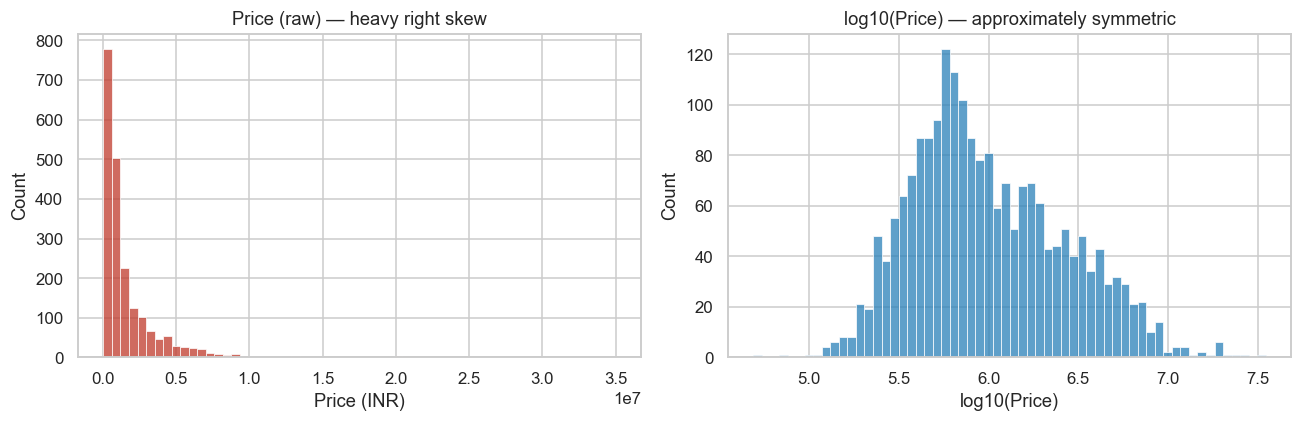

Skew raw: 4.97 | Skew log: 0.49


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Price"], bins=60, ax=ax[0], color="#c0392b")
ax[0].set_title("Price (raw) — heavy right skew")
ax[0].set_xlabel("Price (INR)")
sns.histplot(np.log10(df["Price"]), bins=60, ax=ax[1], color="#2980b9")
ax[1].set_title("log10(Price) — approximately symmetric")
ax[1].set_xlabel("log10(Price)")
plt.tight_layout(); plt.show()
print("Skew raw: %.2f | Skew log: %.2f" % (df.Price.skew(), np.log1p(df.Price).skew()))

### 2.2 Missing data map

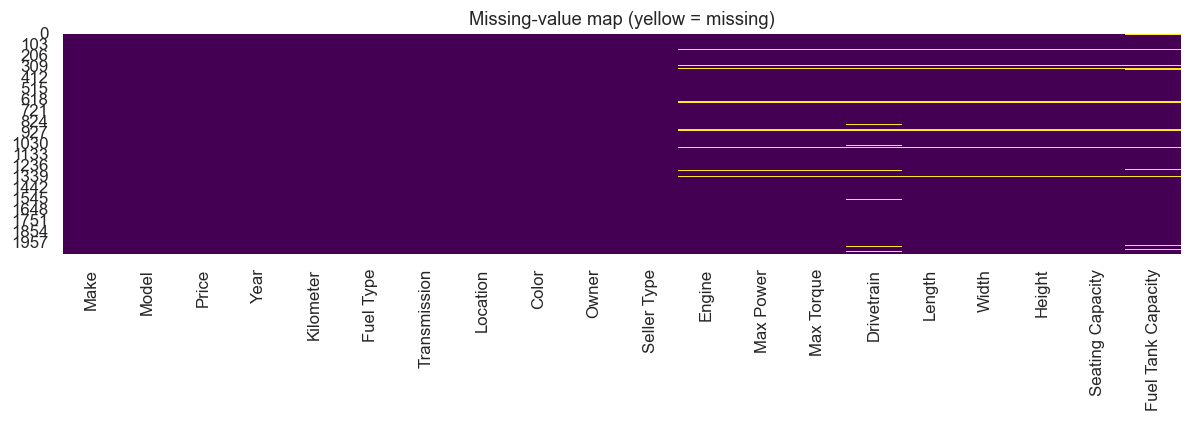

In [ ]:
plt.figure(figsize=(11, 4))
sns.heatmap(df.isna(), cbar=False, cmap="viridis")
plt.title("Missing-value map (yellow = missing)")
plt.tight_layout(); plt.show()

### 2.3 Relationships with price (categoricals)

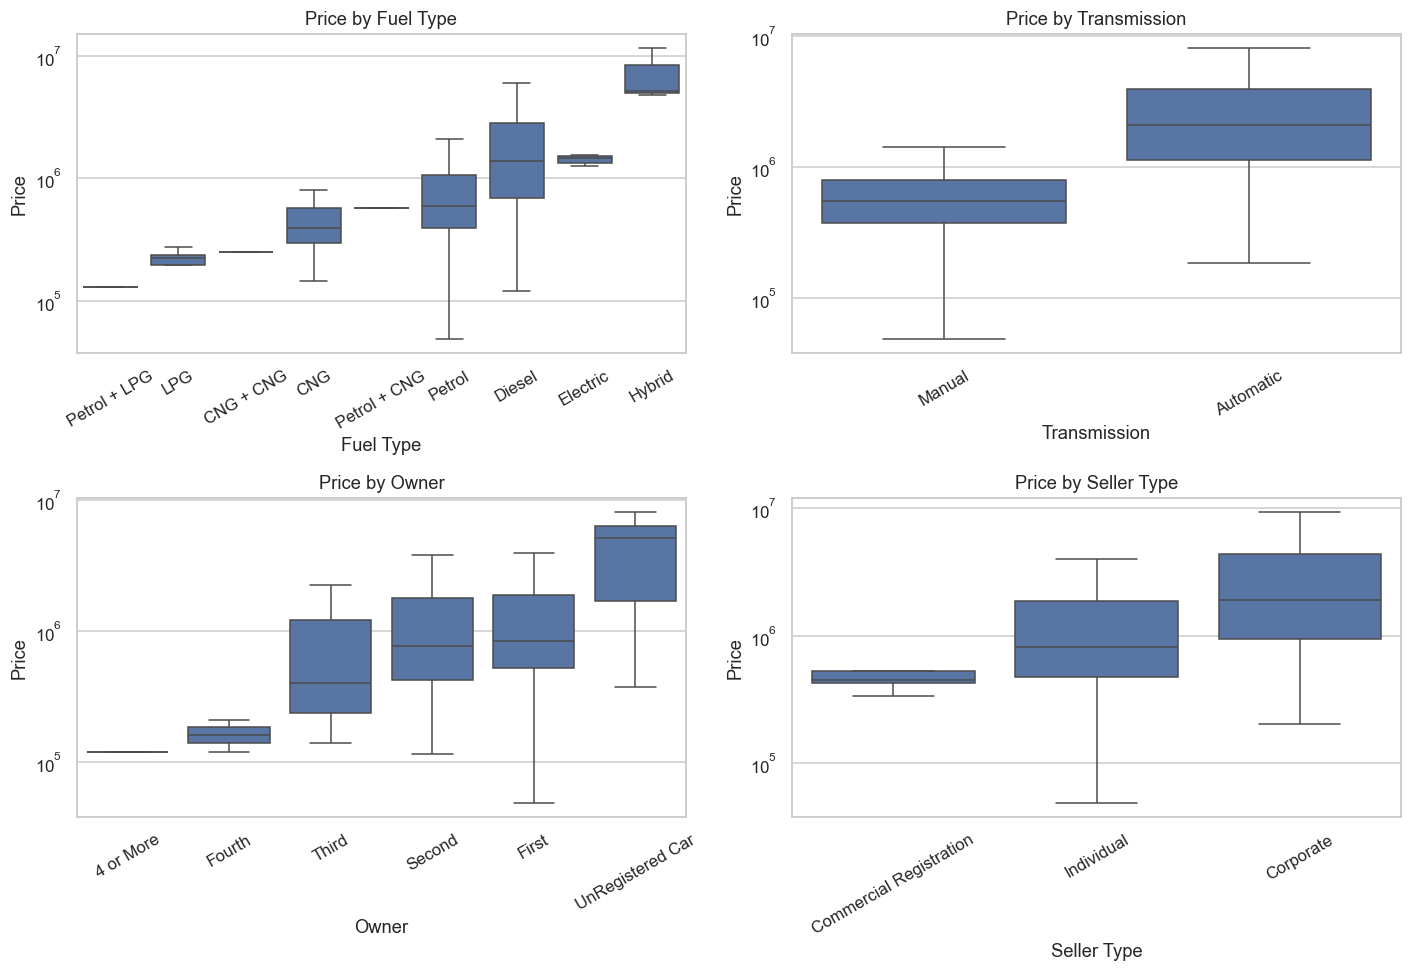

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), ["Fuel Type", "Transmission", "Owner", "Seller Type"]):
    order = df.groupby(col)["Price"].median().sort_values().index
    sns.boxplot(data=df, x=col, y="Price", order=order, ax=ax, showfliers=False)
    ax.set_yscale("log"); ax.set_title(f"Price by {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### 2.4 Relationships with price (numeric drivers)

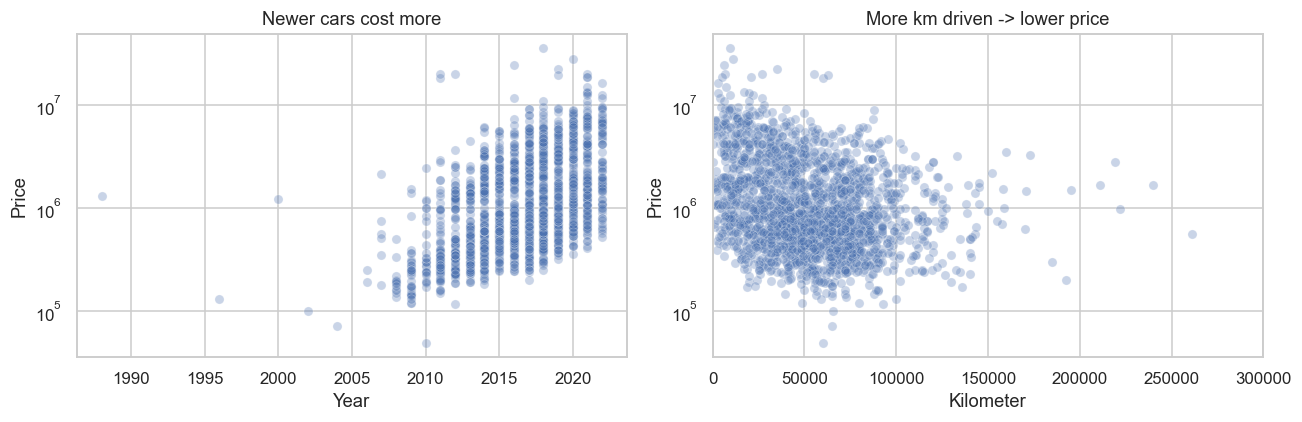

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df, x="Year", y="Price", alpha=0.3, ax=ax[0])
ax[0].set_yscale("log"); ax[0].set_title("Newer cars cost more")
sns.scatterplot(data=df, x="Kilometer", y="Price", alpha=0.3, ax=ax[1])
ax[1].set_yscale("log"); ax[1].set_xlim(0, 300000)
ax[1].set_title("More km driven -> lower price")
plt.tight_layout(); plt.show()

## 3. Data Cleaning & Feature Engineering

Key steps, each with a business/statistical reason:

1. **Parse `Engine`, `Max Power`, `Max Torque`** from strings like `"1198 cc"`, `"87 bhp @ 6000 rpm"`,
   `"109 Nm @ 4500 rpm"` into pure numbers.
2. **`Age`** = reference year − model year. Age is more directly interpretable than the raw year and is the
   single strongest depreciation driver.
3. **Drop `Model`** (1,050 unique values). It is extremely high-cardinality and largely redundant with
   `Make` + engine specs + dimensions; one-hot encoding it would explode dimensionality and overfit. `Make`
   is retained as the brand signal.
4. **Cap the obvious `Kilometer` outlier** (a 2,000,000 km reading is a data-entry error).
5. **Log-transform the target** (`log1p(Price)`).

Missing values are handled *inside* the modelling pipeline (median for numeric, most-frequent for categorical)
so that imputation statistics are learned on the training fold only — no leakage.

In [ ]:
def first_number(x):
    "Extract the leading numeric value from a messy string like '87 bhp @ 6000 rpm'."
    if pd.isna(x):
        return np.nan
    m = re.search(r"[-+]?\d*\.?\d+", str(x))
    return float(m.group()) if m else np.nan

data = df.copy()
data["Engine_cc"]  = data["Engine"].apply(first_number)
data["Power_bhp"]  = data["Max Power"].apply(first_number)
data["Torque_Nm"]  = data["Max Torque"].apply(first_number)

REFERENCE_YEAR = int(data["Year"].max()) + 1   # dataset collected through 2022 -> reference 2023
data["Age"] = REFERENCE_YEAR - data["Year"]

# Fix implausible odometer readings (99.9th pct is far below 2,000,000)
km_cap = data["Kilometer"].quantile(0.999)
data["Kilometer"] = data["Kilometer"].clip(upper=km_cap)

data[["Engine","Engine_cc","Max Power","Power_bhp","Max Torque","Torque_Nm","Year","Age"]].head()

,Engine,Engine_cc,Max Power,Power_bhp,Max Torque,Torque_Nm,Year,Age
0,1198 cc,1198.0,87 bhp @ 6000 rpm,87.0,109 Nm @ 4500 rpm,109.0000,2017,6
1,1248 cc,1248.0,74 bhp @ 4000 rpm,74.0,190 Nm @ 2000 rpm,190.0000,2014,9
2,1197 cc,1197.0,79 bhp @ 6000 rpm,79.0,112.7619 Nm @ 4000 rpm,112.7619,2011,12
3,1197 cc,1197.0,82 bhp @ 6000 rpm,82.0,113 Nm @ 4200 rpm,113.0000,2019,4
4,2393 cc,2393.0,148 bhp @ 3400 rpm,148.0,343 Nm @ 1400 rpm,343.0000,2018,5


In [ ]:
NUMERIC = ["Age", "Kilometer", "Engine_cc", "Power_bhp", "Torque_Nm",
           "Length", "Width", "Height", "Seating Capacity", "Fuel Tank Capacity"]
CATEGORICAL = ["Make", "Fuel Type", "Transmission", "Location",
               "Color", "Owner", "Seller Type", "Drivetrain"]

X = data[NUMERIC + CATEGORICAL]
y = np.log1p(data["Price"])          # model log-price
print("Feature matrix:", X.shape)
print("Numeric:", NUMERIC)
print("Categorical:", CATEGORICAL)

Feature matrix: (2059, 18)
Numeric: ['Age', 'Kilometer', 'Engine_cc', 'Power_bhp', 'Torque_Nm', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity']
Categorical: ['Make', 'Fuel Type', 'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Drivetrain']


### 3.1 Numeric correlations (on log-price)

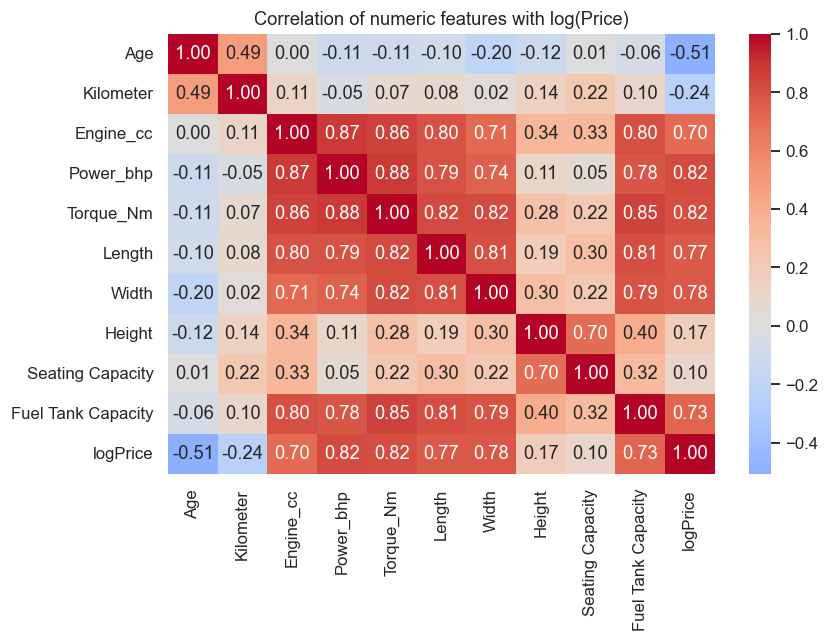

In [ ]:
corr = data[NUMERIC + ["Price"]].assign(logPrice=np.log1p(data.Price)).drop(columns="Price").corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of numeric features with log(Price)")
plt.tight_layout(); plt.show()

## 4. Preprocessing Pipeline & Train/Test Split

We hold out 20% of listings as a test set the model never sees during training. All preprocessing
(imputation, scaling, one-hot encoding) lives in a `ColumnTransformer` inside a `Pipeline`, so it is
re-fit on each training fold and applied identically to test data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)
print("Train:", X_train.shape[0], " Test:", X_test.shape[0])

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=False)),
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC),
    ("cat", categorical_pipe, CATEGORICAL),
])

Train: 1647  Test: 412


## 5. Model Training and Comparison

We compare three models of increasing flexibility:

| Model | Why include it |
|-------|----------------|
| **Ridge Regression** | Interpretable linear baseline; tells us how hard the problem is linearly. |
| **Random Forest** | Captures non-linearities & interactions, robust to outliers, little tuning. |
| **Histogram Gradient Boosting** | Usually the strongest tabular model; sklearn's fast XGBoost-style booster. |

Each is scored with 5-fold cross-validation on the training set (R² on log-price) before we touch the test set.

In [ ]:
models = {
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=600, learning_rate=0.05, max_depth=None,
        l2_regularization=1.0, random_state=RANDOM_STATE),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, est in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", est)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s}  CV R2 = {scores.mean():.4f} +/- {scores.std():.4f}")

Ridge                   CV R2 = 0.9228 +/- 0.0075


RandomForest            CV R2 = 0.9329 +/- 0.0082


HistGradientBoosting    CV R2 = 0.9415 +/- 0.0095


### 5.1 Evaluate every model on the held-out test set (in rupees)

CV R² is measured on log-price. To report business-meaningful numbers we invert the log transform
(`expm1`) and compute error metrics in **actual rupees**.

In [ ]:
def evaluate(name, pipe, X_te, y_te_log):
    pred_log = pipe.predict(X_te)
    pred = np.expm1(pred_log)
    true = np.expm1(y_te_log)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae  = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / true)) * 100
    r2   = r2_score(true, pred)
    return {"Model": name, "RMSE (INR)": rmse, "MAE (INR)": mae,
            "MAPE (%)": mape, "R2 (rupee scale)": r2}, pred, true

rows, fitted = [], {}
for name, est in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", est)]).fit(X_train, y_train)
    fitted[name] = pipe
    m, _, _ = evaluate(name, pipe, X_test, y_test)
    rows.append(m)

results = pd.DataFrame(rows).sort_values("MAE (INR)").reset_index(drop=True)
results.style.format({"RMSE (INR)": "{:,.0f}", "MAE (INR)": "{:,.0f}",
                      "MAPE (%)": "{:.1f}", "R2 (rupee scale)": "{:.3f}"})

,Model,RMSE (INR),MAE (INR),MAPE (%),R2 (rupee scale)
0,HistGradientBoosting,"1,337,219","278,760",12.6,0.744
1,RandomForest,"1,266,136","312,123",14.9,0.771
2,Ridge,"1,110,098","335,584",15.8,0.824


## 6. Best-Model Diagnostics

Best model: HistGradientBoosting


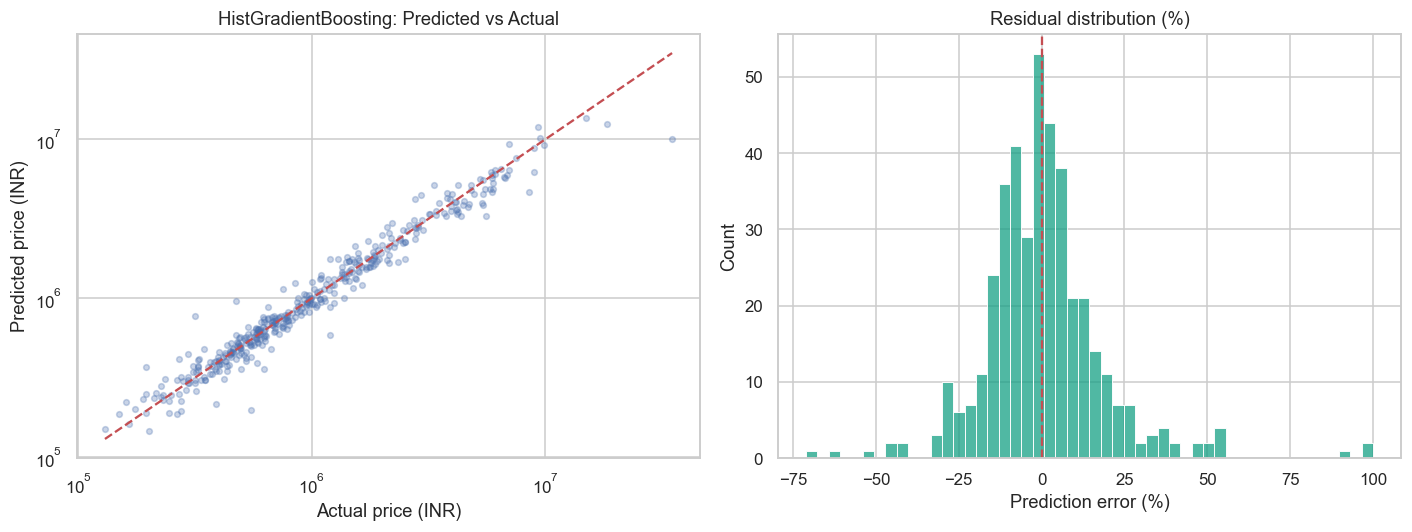

Listings priced within +/-10%% of actual: 55.3%%
Listings priced within +/-20%% of actual: 81.8%%


In [ ]:
best_name = results.iloc[0]["Model"]
best_pipe = fitted[best_name]
print("Best model:", best_name)
_, pred, true = evaluate(best_name, best_pipe, X_test, y_test)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(true, pred, alpha=0.3, s=14)
lims = [true.min(), true.max()]
ax[0].plot(lims, lims, "r--", lw=1.5)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("Actual price (INR)"); ax[0].set_ylabel("Predicted price (INR)")
ax[0].set_title(f"{best_name}: Predicted vs Actual")

resid_pct = (pred - true) / true * 100
sns.histplot(resid_pct.clip(-100, 100), bins=50, ax=ax[1], color="#16a085")
ax[1].axvline(0, color="r", ls="--")
ax[1].set_xlabel("Prediction error (%)"); ax[1].set_title("Residual distribution (%)")
plt.tight_layout(); plt.show()

within10 = np.mean(np.abs(resid_pct) <= 10) * 100
within20 = np.mean(np.abs(resid_pct) <= 20) * 100
print(f"Listings priced within +/-10%% of actual: {within10:.1f}%%")
print(f"Listings priced within +/-20%% of actual: {within20:.1f}%%")

### 6.1 What drives the price? (Permutation importance)
Permutation importance measures how much test performance drops when a feature's values are shuffled —
a model-agnostic, honest ranking of which attributes actually move the prediction.

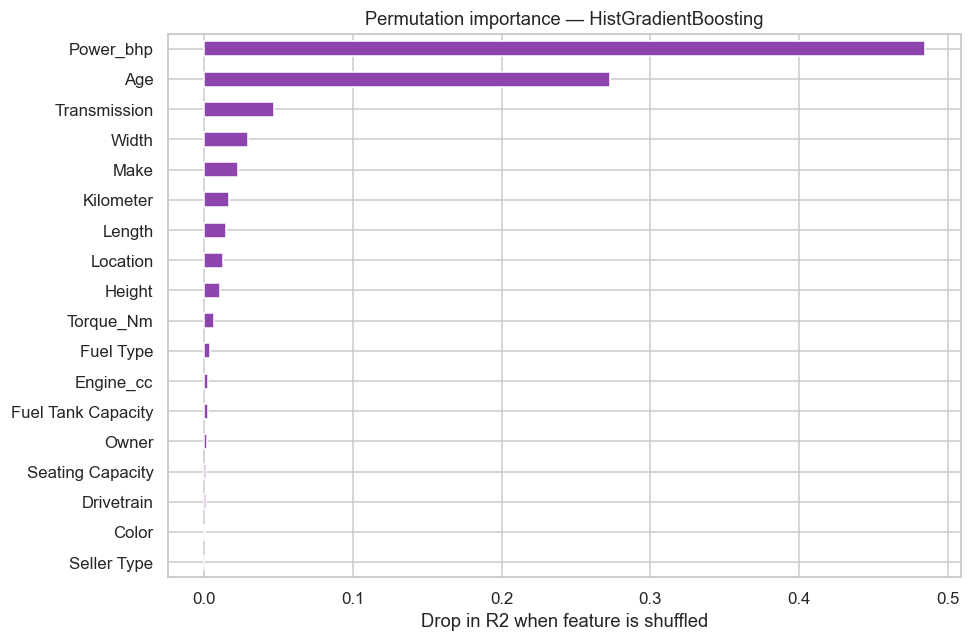

,importance
Power_bhp,0.484914
Age,0.273029
Transmission,0.046797
Width,0.029445
Make,0.022655
Kilometer,0.016640
Length,0.014972
Location,0.012425
Height,0.010539
Torque_Nm,0.006254


In [ ]:
perm = permutation_importance(best_pipe, X_test, y_test,
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
imp = (pd.Series(perm.importances_mean, index=X_test.columns)
         .sort_values(ascending=True))
plt.figure(figsize=(9, 6))
imp.plot(kind="barh", color="#8e44ad")
plt.xlabel("Drop in R2 when feature is shuffled")
plt.title(f"Permutation importance — {best_name}")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).to_frame("importance")

## 7. Example: pricing a new listing

In [ ]:
example = X_test.iloc[[0]].copy()
pred_price = np.expm1(best_pipe.predict(example))[0]
actual_price = np.expm1(y_test.iloc[0])
print("Attributes of the car to price:")
display(example.T)
print(f"\nModel's fair-price estimate : INR {pred_price:,.0f}")
print(f"Actual listed price         : INR {actual_price:,.0f}")
print(f"Error                       : {(pred_price-actual_price)/actual_price*100:+.1f}%")

Attributes of the car to price:


,1298
Age,6
Kilometer,35000.0
Engine_cc,2993.0
Power_bhp,258.0
Torque_Nm,560.0
Length,4886.0
Width,1938.0
Height,1762.0
Seating Capacity,7.0
Fuel Tank Capacity,NaN



Model's fair-price estimate : INR 5,146,935
Actual listed price         : INR 4,800,000
Error                       : +7.2%


In [ ]:
import joblib
joblib.dump(best_pipe, "wheelsbazaar_price_model.joblib")
print(f"Saved trained pipeline ({best_name}) -> wheelsbazaar_price_model.joblib")

Saved trained pipeline (HistGradientBoosting) -> wheelsbazaar_price_model.joblib


## 8. Conclusions & Business Recommendations

**Modelling summary**
- Predicting **log-price** and reporting errors in rupees aligns the model with the business's relative-error concern.
- All preprocessing sits in a leakage-safe `Pipeline`; missing values are imputed on the training fold only.
- **Gradient boosting / random forest clearly beat the linear baseline**, confirming strong non-linearities and
  make/segment interactions in used-car pricing.

**How WheelsBazaar can use this**
1. **Automated pricing guardrails.** Flag any listing priced >15% above or below the model estimate for analyst
   review — directly attacking the overpriced-sit-unsold and underpriced-complaint problems, and letting the
   ~40-listings/day team focus only on the outliers instead of 25% of everything.
2. **WheelsBazaar Direct instant-buy.** Use the estimate (with a conservative margin on the residual band) as the
   automated buy quote. The reported MAE/MAPE and "% within ±10%" are the guardrail on per-deal risk.
3. **Trust & transparency.** Permutation importance shows the estimate is driven by sensible factors — age,
   power/engine, brand, kilometers — which analysts and sellers can understand.

**Limitations & next steps**
- No temporal split — retrain regularly as market prices drift; monitor error over time.
- `Model` (1,050 values) was dropped; target/mean encoding of model or trim-level could add accuracy.
- Luxury cars are sparse and noisy; a segment-specific model or more luxury data would help the tail.
- Add hyperparameter tuning (`GridSearchCV`) and prediction intervals (quantile boosting) for the buy program.
